In [1]:
%%capture
%pip install -r ../requirements.txt

In [2]:
from schema import WLD
from chart_style import (
    CATEGORICAL_COLORS,
    MONO_FONT,
    NOTEBOOK_AXES,
    PALETTE,
    add_footer,
    add_header,
    chart_canvas,
    notebook_frame,
    style_axes,
    style_legend,
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

wld = WLD(file_path="../data/example-chappy.wld")


# Bodyweight-Conditioned Strength Evals

Weekly-bodyweight-aligned strength history, all-attempt Pareto frontiers, and 16:9 benchmark-card exports for bench, squat, deadlift, and overhead press.


## Big Three PRs vs. Bodyweight

The charts below start at the first logged bodyweight week. Bench and squat use their competition lift; deadlift uses whichever running PR was stronger between conventional and sumo. **Combined** is the sum of the three running estimated 1RM records.


In [3]:
from analysis_utils import build_big_three_pr_history

variant_to_lift = {
    "Flat Barbell Bench Press": "Bench",
    "Back Squats": "Squat",
    "Conventional Deadlifts": "Deadlift",
    "Sumo Deadlifts": "Deadlift",
    "Barbell Overhead Press": "Overhead Press",
}

set_records = []
for workout in wld.workouts:
    for exercise in workout.exercises:
        variant = exercise.displayName()
        lift = variant_to_lift.get(variant)
        if lift is None:
            continue
        for set_data in exercise.sets:
            if set_data.oneRM is not None and set_data.oneRM > 0:
                set_records.append({
                    "date": workout.date,
                    "workout_id": workout.uuid,
                    "lift": lift,
                    "one_rm": set_data.oneRM,
                    "variant": variant,
                })

weekly_weights = (
    pd.read_csv("../data/weight.csv", parse_dates=["Week of"])
    .rename(columns={"Week of": "week_of", "Average": "bodyweight"})
)
weekly_weights["bodyweight"] = pd.to_numeric(
    weekly_weights["bodyweight"], errors="coerce"
)
weekly_weights = weekly_weights.dropna(subset=["week_of", "bodyweight"])
weekly_weights = weekly_weights[weekly_weights["bodyweight"] > 0].copy()

pr_history = build_big_three_pr_history(
    pd.DataFrame(set_records), weekly_weights
)

summary = (
    pr_history.sort_values("date")
    .groupby("series", sort=False)
    .agg(
        first_date=("date", "min"),
        latest_date=("date", "max"),
        pr_points=("date", "count"),
        latest_1rme=("one_rm", "last"),
    )
    .reindex(["Combined", "Bench", "Squat", "Deadlift"])
)
summary


,first_date,latest_date,pr_points,latest_1rme
series,,,,
Combined,2018-09-24,2026-07-19,69,1680.0
Bench,2018-09-24,2026-06-17,21,500.0
Squat,2018-09-24,2026-07-19,34,600.0
Deadlift,2018-09-24,2026-07-10,17,580.0


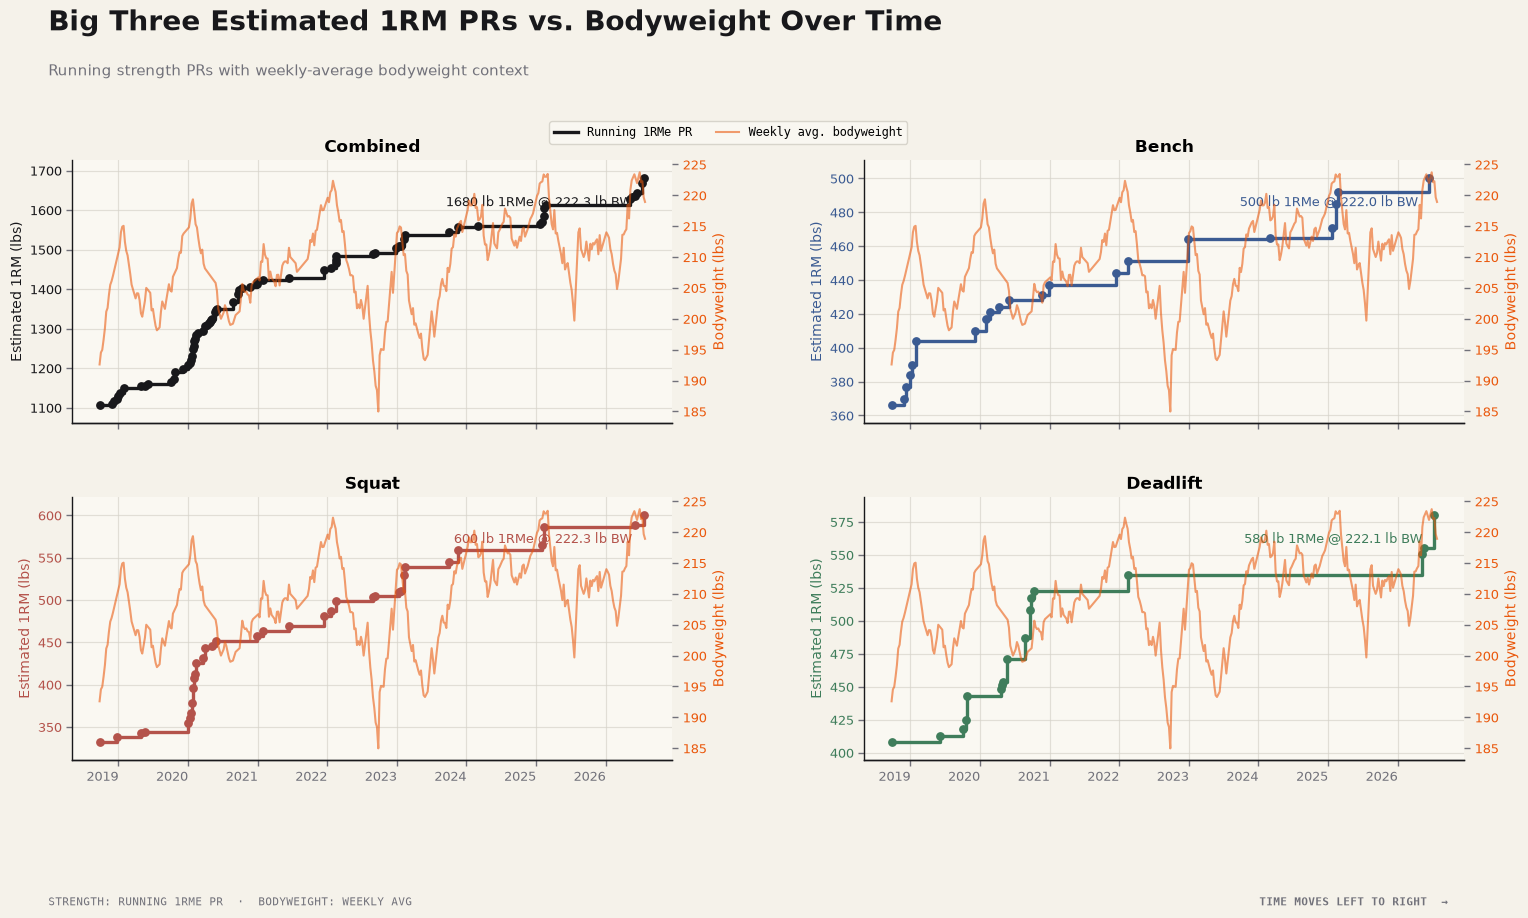

In [4]:
from matplotlib.dates import DateFormatter, YearLocator

series_order = ["Combined", "Bench", "Squat", "Deadlift"]
series_colors = {
    "Combined": PALETTE.ink,
    "Bench": CATEGORICAL_COLORS[0],
    "Squat": CATEGORICAL_COLORS[1],
    "Deadlift": CATEGORICAL_COLORS[2],
}
bodyweight_color = PALETTE.reference
frame = notebook_frame((16, 10))

with chart_canvas(frame) as (fig, seed_ax):
    fig.delaxes(seed_ax)
    axes = fig.subplots(2, 2, sharex=True)
    fig.subplots_adjust(wspace=0.32, hspace=0.28)
    for ax in axes.flat:
        ax.set_facecolor(PALETTE.panel)

    add_header(
        fig,
        frame,
        "Big Three Estimated 1RM PRs vs. Bodyweight Over Time",
        "Running strength PRs with weekly-average bodyweight context",
        (),
    )

    for ax, series in zip(axes.flat, series_order):
        points = pr_history[pr_history["series"] == series].sort_values("date")
        ax.step(
            points["date"],
            points["one_rm"],
            where="post",
            color=series_colors[series],
            linewidth=2.4,
            label=f"{series} 1RMe PR",
        )
        ax.scatter(
            points["date"],
            points["one_rm"],
            color=series_colors[series],
            s=28,
            zorder=3,
        )
        ax.set_title(series, fontweight="bold")
        ax.set_ylabel("Estimated 1RM (lbs)", color=series_colors[series])
        ax.tick_params(axis="y", labelcolor=series_colors[series])
        style_axes(ax, NOTEBOOK_AXES)

        weight_ax = ax.twinx()
        weight_ax.plot(
            weekly_weights["week_of"],
            weekly_weights["bodyweight"],
            color=bodyweight_color,
            linewidth=1.5,
            alpha=0.58,
            label="Weekly avg. bodyweight",
        )
        weight_ax.set_ylabel("Bodyweight (lbs)", color=bodyweight_color)
        weight_ax.tick_params(axis="y", labelcolor=bodyweight_color)
        style_axes(weight_ax, NOTEBOOK_AXES)
        weight_ax.grid(False)
        weight_ax.spines["left"].set_visible(False)

        latest = points.iloc[-1]
        latest_bw = latest["bodyweight"]
        latest_label = f'{latest["one_rm"]:.0f} lb 1RMe'
        if pd.notna(latest_bw):
            latest_label += f' @ {latest_bw:.1f} lb BW'
        ax.annotate(
            latest_label,
            (latest["date"], latest["one_rm"]),
            xytext=(-8, -12),
            textcoords="offset points",
            ha="right",
            va="top",
            fontsize=9,
            color=series_colors[series],
        )

        ax.margins(y=0.08)
        ax.xaxis.set_major_locator(YearLocator())
        ax.xaxis.set_major_formatter(DateFormatter("%Y"))

    handles = [
        plt.Line2D(
            [0], [0], color=PALETTE.ink, linewidth=2.4, label="Running 1RMe PR"
        ),
        plt.Line2D(
            [0],
            [0],
            color=bodyweight_color,
            linewidth=1.5,
            alpha=0.58,
            label="Weekly avg. bodyweight",
        ),
    ]
    style_legend(
        axes.flat[0],
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.845),
        bbox_transform=fig.transFigure,
        ncol=2,
    )
    add_footer(
        fig,
        frame,
        "STRENGTH: RUNNING 1RME PR  ·  BODYWEIGHT: WEEKLY AVG",
        "TIME MOVES LEFT TO RIGHT  →",
    )
    fig.autofmt_xdate(rotation=0)
    plt.show()


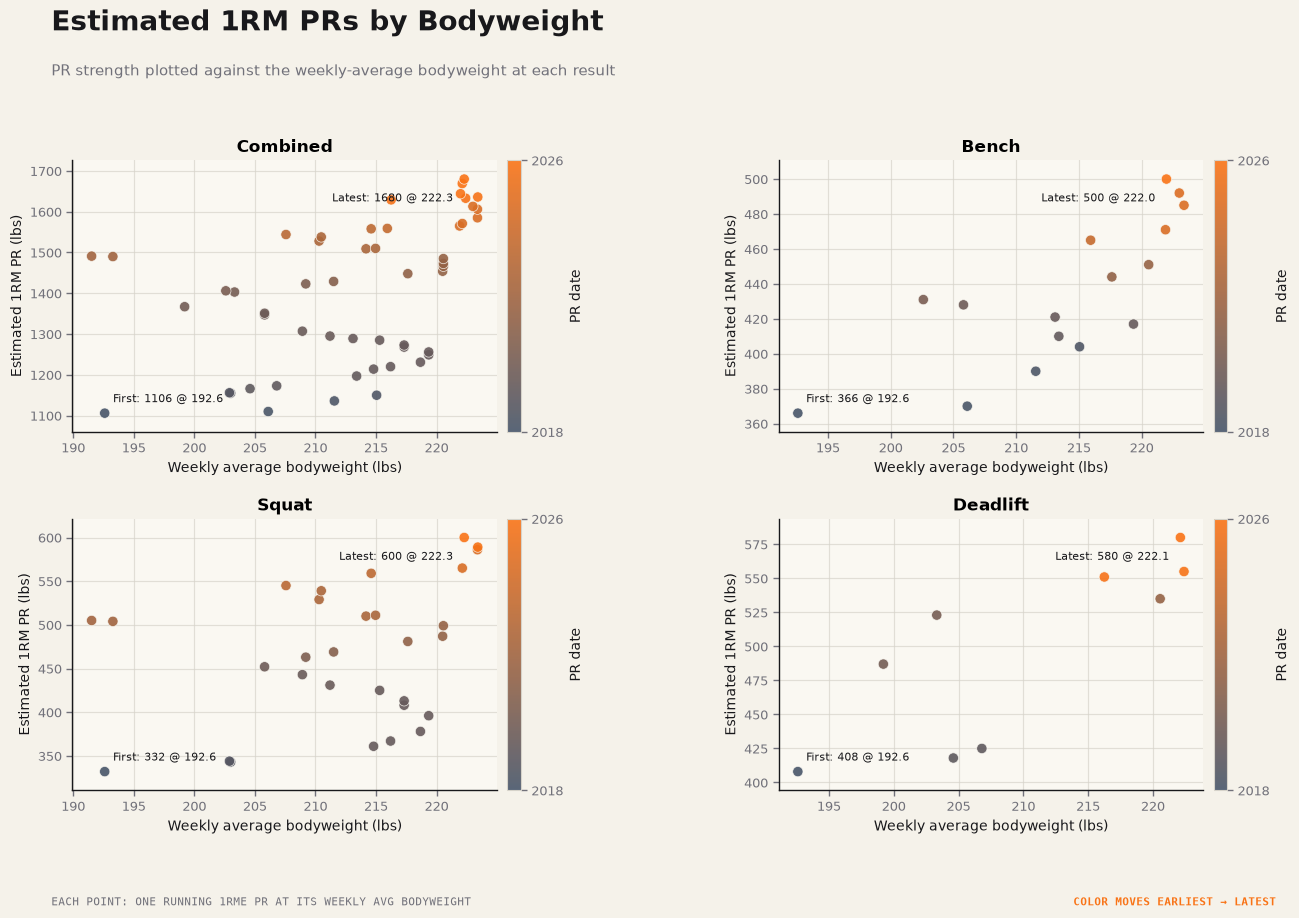

In [5]:
from matplotlib.colors import LinearSegmentedColormap

frame = notebook_frame((14, 10))
date_cmap = LinearSegmentedColormap.from_list(
    "shared_pr_date", [PALETTE.neutral_point, PALETTE.latest]
)

with chart_canvas(frame) as (fig, seed_ax):
    fig.delaxes(seed_ax)
    axes = fig.subplots(2, 2)
    fig.subplots_adjust(wspace=0.38, hspace=0.32)
    for ax in axes.flat:
        ax.set_facecolor(PALETTE.panel)

    add_header(
        fig,
        frame,
        "Estimated 1RM PRs by Bodyweight",
        "PR strength plotted against the weekly-average bodyweight at each result",
        (),
    )

    for ax, series in zip(axes.flat, series_order):
        points = (
            pr_history[pr_history["series"] == series]
            .dropna(subset=["bodyweight"])
            .sort_values("date")
            .copy()
        )
        date_number = points["date"].map(pd.Timestamp.toordinal)
        scatter = ax.scatter(
            points["bodyweight"],
            points["one_rm"],
            c=date_number,
            cmap=date_cmap,
            s=55,
            edgecolor=PALETTE.panel,
            linewidth=0.5,
            alpha=0.9,
        )
        ax.set_title(series, fontweight="bold")
        ax.set_xlabel("Weekly average bodyweight (lbs)")
        ax.set_ylabel("Estimated 1RM PR (lbs)")
        style_axes(ax, NOTEBOOK_AXES)
        ax.margins(x=0.05, y=0.08)

        first, latest = points.iloc[0], points.iloc[-1]
        for label, point in [("First", first), ("Latest", latest)]:
            is_latest = label == "Latest"
            ax.annotate(
                f'{label}: {point["one_rm"]:.0f} @ {point["bodyweight"]:.1f}',
                (point["bodyweight"], point["one_rm"]),
                xytext=(-8, -10) if is_latest else (6, 6),
                textcoords="offset points",
                ha="right" if is_latest else "left",
                va="top" if is_latest else "bottom",
                fontsize=8,
                color=PALETTE.ink,
            )

        colorbar = fig.colorbar(scatter, ax=ax, pad=0.02)
        ticks = [date_number.min(), date_number.max()]
        colorbar.set_ticks(ticks)
        colorbar.set_ticklabels(
            [
                points["date"].iloc[0].strftime("%Y"),
                points["date"].iloc[-1].strftime("%Y"),
            ]
        )
        colorbar.set_label("PR date")
        colorbar.ax.tick_params(
            labelsize=NOTEBOOK_AXES.tick_size,
            width=NOTEBOOK_AXES.tick_width,
            length=NOTEBOOK_AXES.tick_length,
            colors=PALETTE.muted,
        )
        colorbar.outline.set_edgecolor(PALETTE.grid)

    add_footer(
        fig,
        frame,
        "EACH POINT: ONE RUNNING 1RME PR AT ITS WEEKLY AVG BODYWEIGHT",
        "COLOR MOVES EARLIEST → LATEST",
        right_color=PALETTE.latest,
    )
    plt.show()


## Individual-lift Pareto frontiers

Every estimated-1RM attempt that can be matched to a logged weekly-average bodyweight is plotted. The highlighted frontier contains performances for which there is no equally strong or stronger attempt at an equal or lighter bodyweight. Earlier attempts without bodyweight data are necessarily excluded.


In [6]:
from pathlib import Path

from analysis_utils import build_trimmed_trailing_bodyweight, mark_pareto_frontier
from generate_bench_frontier_update import load_daily_weights

daily_weights = load_daily_weights(
    Path.home()
    / "Library/Mobile Documents/com~apple~CloudDocs/Spreadsheets/Weight Log.xlsx"
)
trailing_weights = build_trimmed_trailing_bodyweight(daily_weights)

attempts = pd.DataFrame(set_records).copy()
attempts["date"] = pd.to_datetime(attempts["date"]).dt.normalize()
attempts = attempts.merge(trailing_weights, on="date", how="left")
attempts = attempts.dropna(subset=["bodyweight"]).copy()

pareto_attempts = pd.concat(
    [
        mark_pareto_frontier(attempts[attempts["lift"] == lift])
        for lift in ["Bench", "Squat", "Deadlift", "Overhead Press"]
    ],
    ignore_index=True,
)

pareto_summary = (
    pareto_attempts[pareto_attempts["is_pareto"]]
    .sort_values(["lift", "bodyweight", "one_rm"])
    .groupby("lift")
    .agg(
        frontier_points=("date", "count"),
        lightest_frontier_bw=("bodyweight", "min"),
        strongest_frontier_1rme=("one_rm", "max"),
    )
    .reindex(["Bench", "Squat", "Deadlift", "Overhead Press"])
)
pareto_summary


,frontier_points,lightest_frontier_bw,strongest_frontier_1rme
lift,,,
Bench,20,189.15,500
Squat,13,188.42,600
Deadlift,5,189.15,580
Overhead Press,9,188.42,289


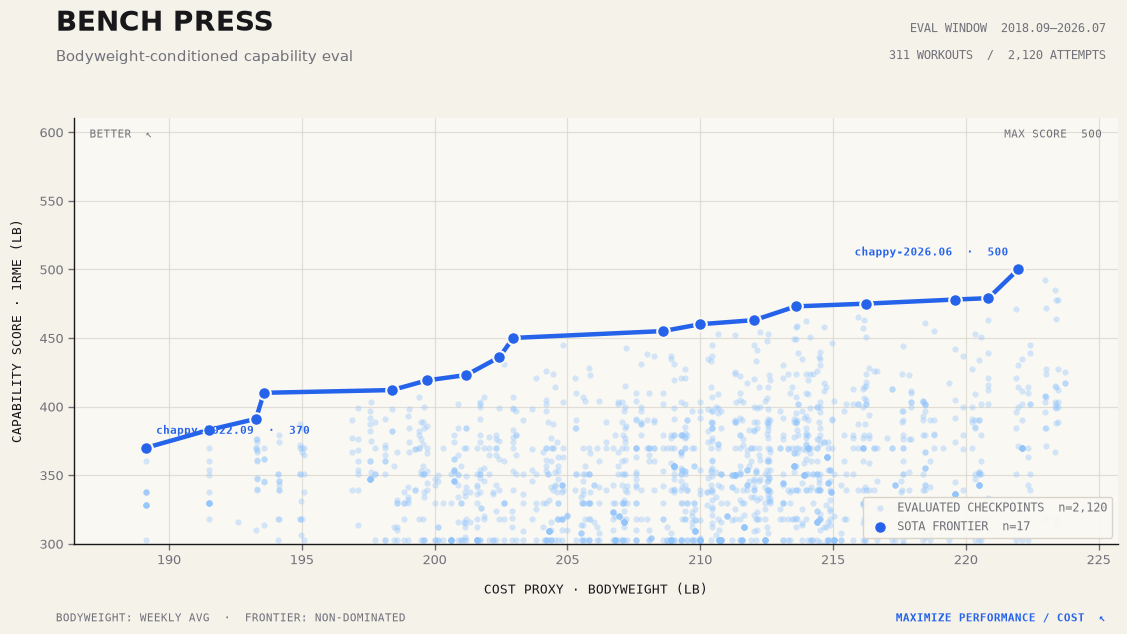

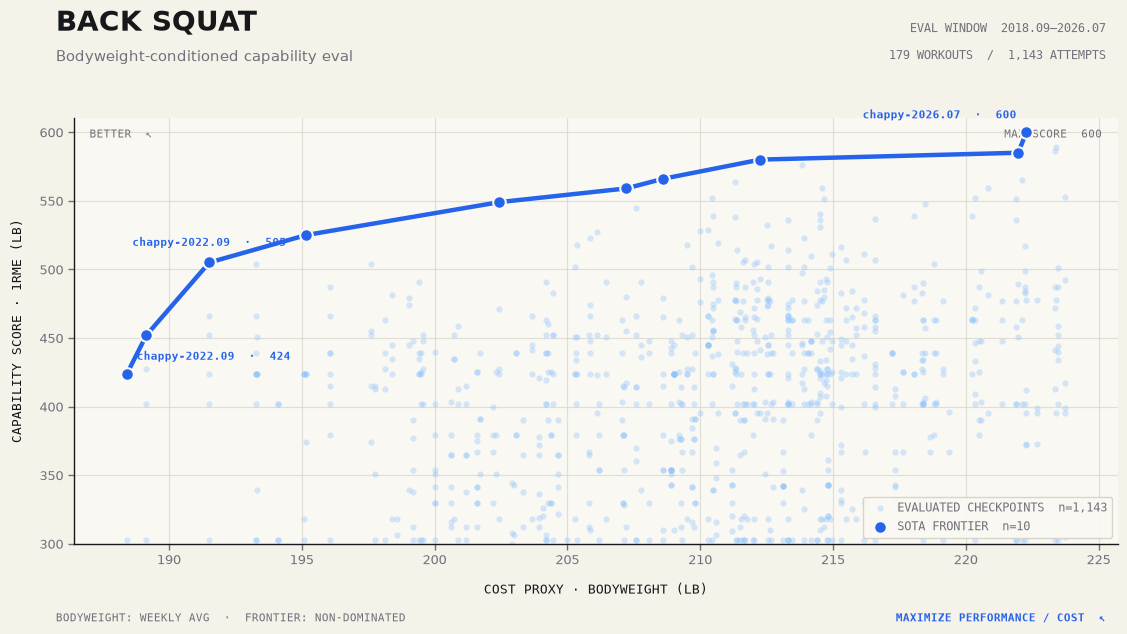

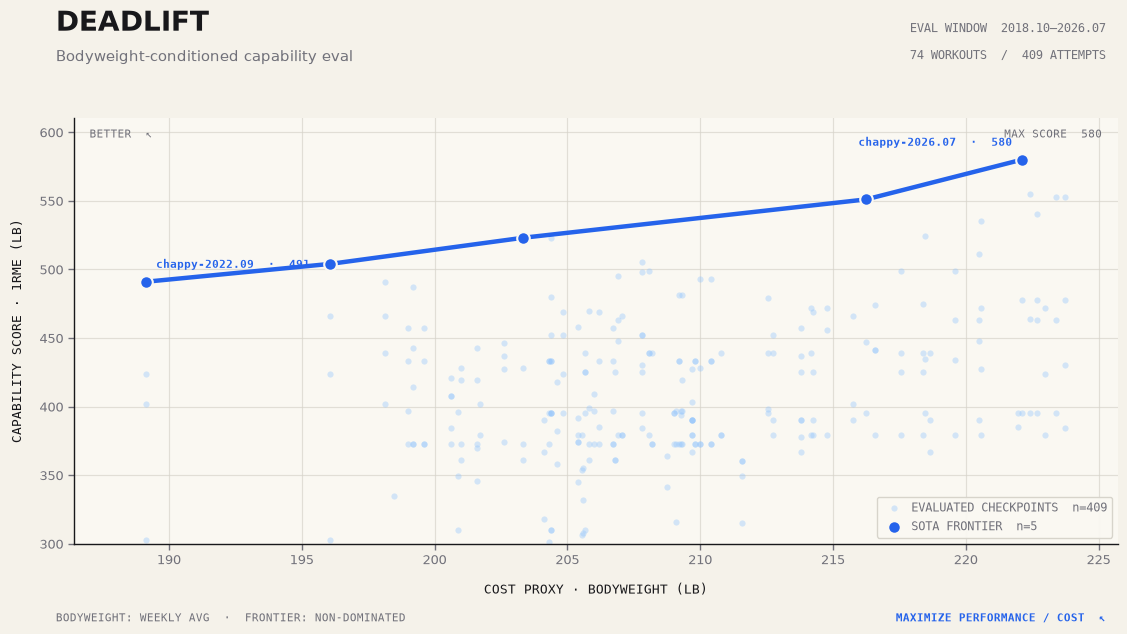

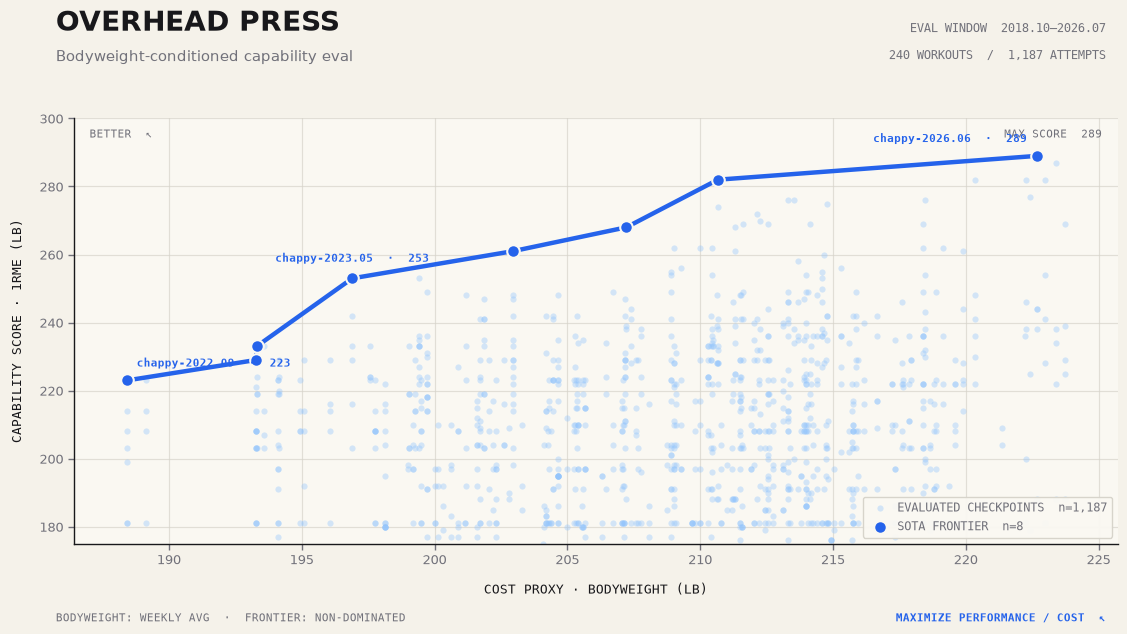

,lift,date,bodyweight,one_rm,variant
1066,Bench,2022-09-12,189.150000,370,Flat Barbell Bench Press
1074,Bench,2022-09-09,191.520000,383,Flat Barbell Bench Press
1091,Bench,2022-08-31,193.275000,391,Flat Barbell Bench Press
830,Bench,2023-05-24,193.575000,410,Flat Barbell Bench Press
864,Bench,2023-04-19,198.400000,412,Flat Barbell Bench Press
285,Bench,2025-07-22,199.700000,419,Flat Barbell Bench Press
806,Bench,2023-07-07,201.200000,423,Flat Barbell Bench Press
292,Bench,2025-07-17,202.440000,436,Flat Barbell Bench Press
909,Bench,2023-03-07,202.960000,450,Flat Barbell Bench Press
319,Bench,2025-06-11,208.600000,455,Flat Barbell Bench Press


In [7]:
from pathlib import Path

lift_order = ["Bench", "Squat", "Deadlift", "Overhead Press"]
lift_display = {"Bench": "BENCH PRESS", "Squat": "BACK SQUAT", "Deadlift": "DEADLIFT", "Overhead Press": "OVERHEAD PRESS"}
lift_y_limits = {"Bench": (300, 610), "Squat": (300, 610), "Deadlift": (300, 610), "Overhead Press": (175, 300)}
lift_output_slugs = {"Bench": "bench", "Squat": "squat", "Deadlift": "deadlift", "Overhead Press": "overhead-press"}

output_dir = Path("../outputs")
output_dir.mkdir(exist_ok=True)

x_min = pareto_attempts["bodyweight"].min() - 2
x_max = pareto_attempts["bodyweight"].max() + 2
frame = notebook_frame((12, 6.75))

for lift in lift_order:
    lift_attempts = pareto_attempts[pareto_attempts["lift"] == lift].copy()
    frontier = (
        lift_attempts[lift_attempts["is_pareto"]]
        .sort_values(["bodyweight", "one_rm"])
        .drop_duplicates(["bodyweight", "one_rm"])
    )
    eval_start = lift_attempts["date"].min()
    eval_end = lift_attempts["date"].max()
    eval_workouts = lift_attempts["workout_id"].nunique()

    with chart_canvas(frame) as (fig, ax):
        add_header(
            fig,
            frame,
            lift_display[lift],
            "Bodyweight-conditioned capability eval",
            (
                f"EVAL WINDOW  {eval_start:%Y.%m}–{eval_end:%Y.%m}",
                f"{eval_workouts:,} WORKOUTS  /  {len(lift_attempts):,} ATTEMPTS",
            ),
        )

        ax.scatter(
            lift_attempts["bodyweight"],
            lift_attempts["one_rm"],
            s=20,
            color=PALETTE.checkpoint,
            alpha=0.38,
            linewidth=0,
            rasterized=True,
            label=f"EVALUATED CHECKPOINTS  n={len(lift_attempts):,}",
        )
        ax.plot(
            frontier["bodyweight"],
            frontier["one_rm"],
            color=PALETTE.frontier,
            linewidth=3.2,
            zorder=3,
        )
        ax.scatter(
            frontier["bodyweight"],
            frontier["one_rm"],
            s=82,
            color=PALETTE.frontier,
            edgecolor=PALETTE.panel,
            linewidth=1.5,
            zorder=4,
            label=f"SOTA FRONTIER  n={len(frontier)}",
        )

        # Keep mobile callouts sparse: smallest checkpoint, largest capability
        # jump, and highest-scoring checkpoint.
        strength_gain = frontier["one_rm"].diff()
        callout_positions = sorted({0, strength_gain.fillna(-1).argmax(), len(frontier) - 1})
        for position in callout_positions:
            point = frontier.iloc[position]
            checkpoint = f'chappy-{point["date"]:%Y.%m}'
            if position == 0:
                xytext, ha = (7, 8), "left"
            elif position == len(frontier) - 1:
                xytext, ha = (-7, 8), "right"
            else:
                xytext, ha = (0, 10), "center"
            ax.annotate(
                f'{checkpoint}  ·  {point["one_rm"]:.0f}',
                (point["bodyweight"], point["one_rm"]),
                xytext=xytext,
                textcoords="offset points",
                ha=ha,
                va="bottom",
                fontsize=8.2,
                family=MONO_FONT,
                color=PALETTE.frontier,
                fontweight="bold",
                zorder=5,
            )

        ax.text(
            0.015,
            0.975,
            "BETTER  ↖",
            transform=ax.transAxes,
            fontsize=8,
            family=MONO_FONT,
            color=PALETTE.muted,
            ha="left",
            va="top",
        )
        ax.text(
            0.985,
            0.975,
            f"MAX SCORE  {frontier['one_rm'].max():.0f}",
            transform=ax.transAxes,
            fontsize=8,
            family=MONO_FONT,
            color=PALETTE.muted,
            ha="right",
            va="top",
        )
        ax.set_xlabel("COST PROXY · BODYWEIGHT (LB)", fontsize=9.5, family=MONO_FONT, labelpad=11)
        ax.set_ylabel("CAPABILITY SCORE · 1RME (LB)", fontsize=9.5, family=MONO_FONT, labelpad=11)
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(*lift_y_limits[lift])
        style_axes(ax, NOTEBOOK_AXES)
        style_legend(
            ax,
            loc="lower right",
            labelcolor=PALETTE.muted,
            handletextpad=0.5,
        )
        add_footer(
            fig,
            frame,
            "BODYWEIGHT: TRAILING 7D TRIMMED AVG  ·  FRONTIER: NON-DOMINATED",
            "MAXIMIZE PERFORMANCE / COST  ↖",
            right_color=PALETTE.frontier,
        )

        output_path = output_dir / f"{lift_output_slugs[lift]}-strength-eval.png"
        fig.savefig(output_path, dpi=200, facecolor=fig.get_facecolor())
        plt.show()

frontier_table = (
    pareto_attempts[pareto_attempts["is_pareto"]]
    .sort_values(["lift", "bodyweight", "one_rm"])
    .drop_duplicates(["lift", "bodyweight", "one_rm"])
    [["lift", "date", "bodyweight", "one_rm", "variant"]]
)
frontier_table
